
# Problem Statement

India’s growing population and rapid industrial development have increased the demand for energy. Traditional non-renewable energy sources such as coal and oil contribute heavily to pollution, carbon emissions, and environmental damage. At the same time, renewable energy sources like solar, wind, and hydro power are becoming more important for sustainable development.

The challenge is to compare renewable and non-renewable energy sources based on factors such as energy production, cost, sustainability, carbon emissions, reliability, and employment generation. The project aims to analyze energy-related data and build machine learning models that can help predict and identify the most sustainable and efficient energy sources for future growth in India.

---

# Objectives of the Project

1. To analyze different energy sources using data analysis techniques.

2. To compare renewable and non-renewable energy sources based on:
   - Energy production
   - Energy consumption
   - Cost per kWh
   - CO2 emissions
   - Sustainability index
   - Reliability
   - Employment generation

3. To perform data preprocessing and visualization for better understanding of energy trends.

4. To identify the environmental and economic impact of various energy sources.

5. To apply machine learning algorithms such as:
   - Random Forest
   - Decision Tree
   - XGBoost

6. To evaluate and compare model performance for energy source prediction.

7. To provide insights that support sustainable energy planning and decision-making in India.

8. To encourage the adoption of cleaner and more sustainable energy resources for future development.


# Capstone Project: Energy Source Prediction and Comparative Study for Sustainable Growth in India

## Project Overview
This capstone project compares renewable and non-renewable energy sources across multiple dimensions:
- Cost analysis
- Sustainability
- Environmental impact
- Employment generation
- Government subsidies
- Energy generation efficiency

The project also uses Machine Learning models to:
1. Predict Energy Type (Renewable / Non-Renewable)
2. Analyze important factors affecting sustainability
3. Forecast future trends and compare energy sources

---

## Technologies Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Jupyter Notebook

---

## Dataset Description
The dataset contains various energy-related attributes such as:
- Installation Cost
- Generation Cost
- CO2 Emission
- Employment
- Sustainability
- Government Subsidies
- Transmission Loss
- Electricity Generation
- Risk Factors

The objective is to analyze how renewable and non-renewable sources differ and identify the most sustainable options for India.


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# Load Dataset
# IMPORTANT:
# Keep your CSV file in the same folder as this notebook
# OR provide the full file path below.

df = pd.read_csv("CAPSTONE PROJECT.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (100, 22)


,Energy Source,Energy Type,Installation Cost (INR per kW),Land Requirement (Acres per MW),Generation Cost (INR per unit),Manpower Required (per MW),Automation Level,O&M Cost (% of Capital),Purpose of Energy,CO2 Emission (kg per kWh),...,Available Employment,Sustainability,Cost of Natural Resource,Percentage of Generation (India),Effect on Economy,Government Subsidy Availability,Selling Price per Unit (INR),Transmission Loss (%),Shutdown Risk,Generation of Electricity (kWh per kW per year)
0,Fossil Fuel,Non-Renewable,52965,0.94,6.86,15,Medium,4.95,Electricity,0.828,...,High,Non-Sustainable,2951,53.17,Negative,Low,7.43,20.60,Medium,8126
1,Tidal/Wave,Renewable,131277,4.27,6.60,5,High,3.75,Electricity,0.000,...,Low,Sustainable,0,1.97,Positive,Low,7.19,9.20,Medium,4459
2,Wind,Renewable,54559,2.19,3.31,5,High,2.05,Electricity,0.020,...,Medium,Sustainable,0,34.77,Positive,High,4.29,7.25,Low,2860
3,Solar,Renewable,41085,5.45,4.37,5,High,1.44,Electricity,0.046,...,High,Sustainable,0,24.70,Positive,High,4.16,7.99,Low,1470
4,Fossil Fuel,Non-Renewable,46733,0.98,6.09,16,Medium,4.93,Electricity,0.847,...,High,Non-Sustainable,3081,49.84,Negative,Low,8.55,19.80,Medium,8130


## Dataset Information

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 22 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Energy Source                                    100 non-null    object 
 1   Energy Type                                      100 non-null    object 
 2   Installation Cost (INR per kW)                   100 non-null    int64  
 3   Land Requirement (Acres per MW)                  100 non-null    float64
 4   Generation Cost (INR per unit)                   100 non-null    float64
 5   Manpower Required (per MW)                       100 non-null    int64  
 6   Automation Level                                 100 non-null    object 
 7   O&M Cost (% of Capital)                          100 non-null    float64
 8   Purpose of Energy                                100 non-null    object 
 9   CO2 Emission (kg per kWh)        

## Checking Missing Values

In [3]:
df.isnull().sum()

Energy Source                                      0
Energy Type                                        0
Installation Cost (INR per kW)                     0
Land Requirement (Acres per MW)                    0
Generation Cost (INR per unit)                     0
Manpower Required (per MW)                         0
Automation Level                                   0
O&M Cost (% of Capital)                            0
Purpose of Energy                                  0
CO2 Emission (kg per kWh)                          0
Effect on Global Warming                           0
Effect of Natural Disaster                         0
Available Employment                               0
Sustainability                                     0
Cost of Natural Resource                           0
Percentage of Generation (India)                   0
Effect on Economy                                  0
Government Subsidy Availability                    0
Selling Price per Unit (INR)                  

## Statistical Summary

In [4]:
df.describe(include='all')

,Energy Source,Energy Type,Installation Cost (INR per kW),Land Requirement (Acres per MW),Generation Cost (INR per unit),Manpower Required (per MW),Automation Level,O&M Cost (% of Capital),Purpose of Energy,CO2 Emission (kg per kWh),...,Available Employment,Sustainability,Cost of Natural Resource,Percentage of Generation (India),Effect on Economy,Government Subsidy Availability,Selling Price per Unit (INR),Transmission Loss (%),Shutdown Risk,Generation of Electricity (kWh per kW per year)
count,100,100,100.000000,100.000000,100.000000,100.000000,100,100.00000,100,100.000000,...,100,100,100.000000,100.000000,100,100,100.000000,100.000000,100,100.000000
unique,8,2,NaN,NaN,NaN,NaN,2,NaN,2,NaN,...,3,4,NaN,NaN,5,3,NaN,NaN,3,NaN
top,Fossil Fuel,Renewable,NaN,NaN,NaN,NaN,High,NaN,Electricity,NaN,...,High,Sustainable,NaN,NaN,Positive,Low,NaN,NaN,Medium,NaN
freq,19,67,NaN,NaN,NaN,NaN,74,NaN,84,NaN,...,48,51,NaN,NaN,48,44,NaN,NaN,37,NaN
mean,NaN,NaN,80811.140000,3.426400,4.952200,9.820000,NaN,3.55920,NaN,0.220740,...,NaN,NaN,889.220000,23.513300,NaN,NaN,5.814300,9.886300,NaN,5486.320000
std,NaN,NaN,36470.063258,2.696303,1.392305,5.661102,NaN,1.57959,NaN,0.343571,...,NaN,NaN,1183.665123,18.498197,NaN,NaN,1.696341,4.998199,NaN,2639.188726
min,NaN,NaN,41085.000000,0.900000,2.750000,4.000000,NaN,1.37000,NaN,0.000000,...,NaN,NaN,0.000000,1.800000,NaN,NaN,3.270000,5.430000,NaN,1258.000000
25%,NaN,NaN,50252.750000,1.540000,3.780000,5.000000,NaN,2.14750,NaN,0.018000,...,NaN,NaN,0.000000,8.327500,NaN,NaN,4.237500,6.885000,NaN,2833.750000
50%,NaN,NaN,65848.000000,2.105000,4.805000,7.000000,NaN,3.24000,NaN,0.033500,...,NaN,NaN,0.000000,20.400000,NaN,NaN,5.820000,7.565000,NaN,5686.500000
75%,NaN,NaN,101131.250000,4.620000,6.250000,14.250000,NaN,5.05250,NaN,0.369250,...,NaN,NaN,1629.750000,35.405000,NaN,NaN,7.275000,9.512500,NaN,8090.000000


## Data Visualization

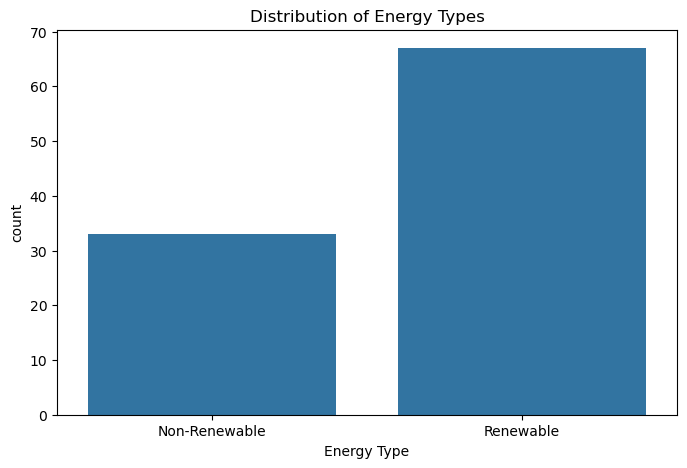

In [5]:
# Countplot for Energy Types

plt.figure(figsize=(8,5))
sns.countplot(x='Energy Type', data=df)
plt.title("Distribution of Energy Types")
plt.show()


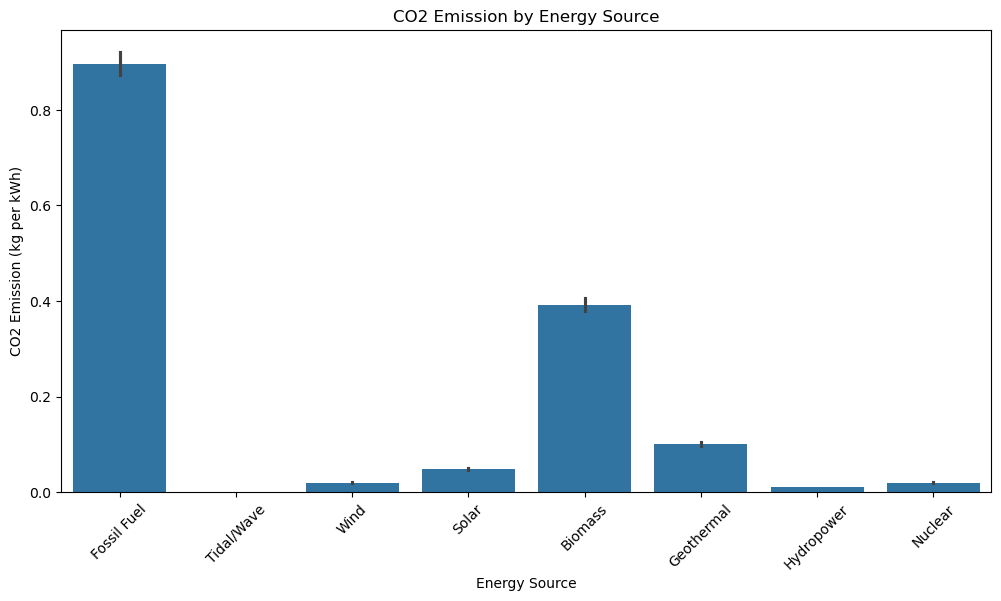

In [6]:
# CO2 Emission by Energy Source

plt.figure(figsize=(12,6))
sns.barplot(x='Energy Source', y='CO2 Emission (kg per kWh)', data=df)
plt.xticks(rotation=45)
plt.title("CO2 Emission by Energy Source")
plt.show()


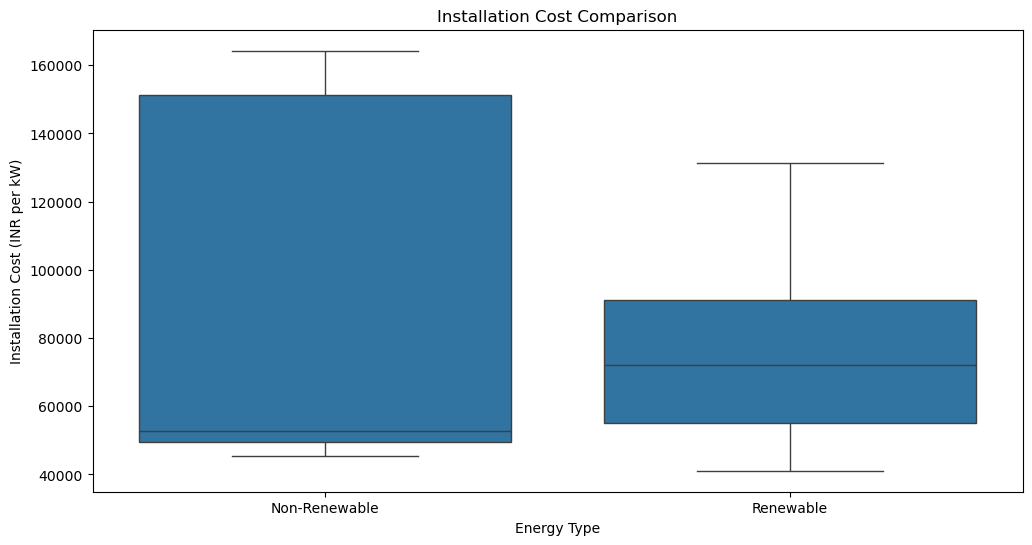

In [7]:
# Installation Cost Comparison

plt.figure(figsize=(12,6))
sns.boxplot(x='Energy Type', y='Installation Cost (INR per kW)', data=df)
plt.title("Installation Cost Comparison")
plt.show()


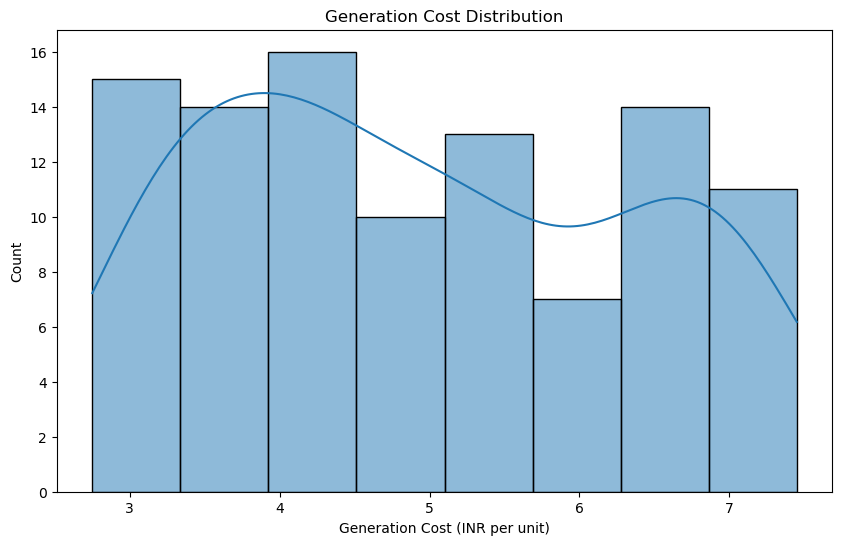

In [8]:
# Generation Cost Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['Generation Cost (INR per unit)'], kde=True)
plt.title("Generation Cost Distribution")
plt.show()


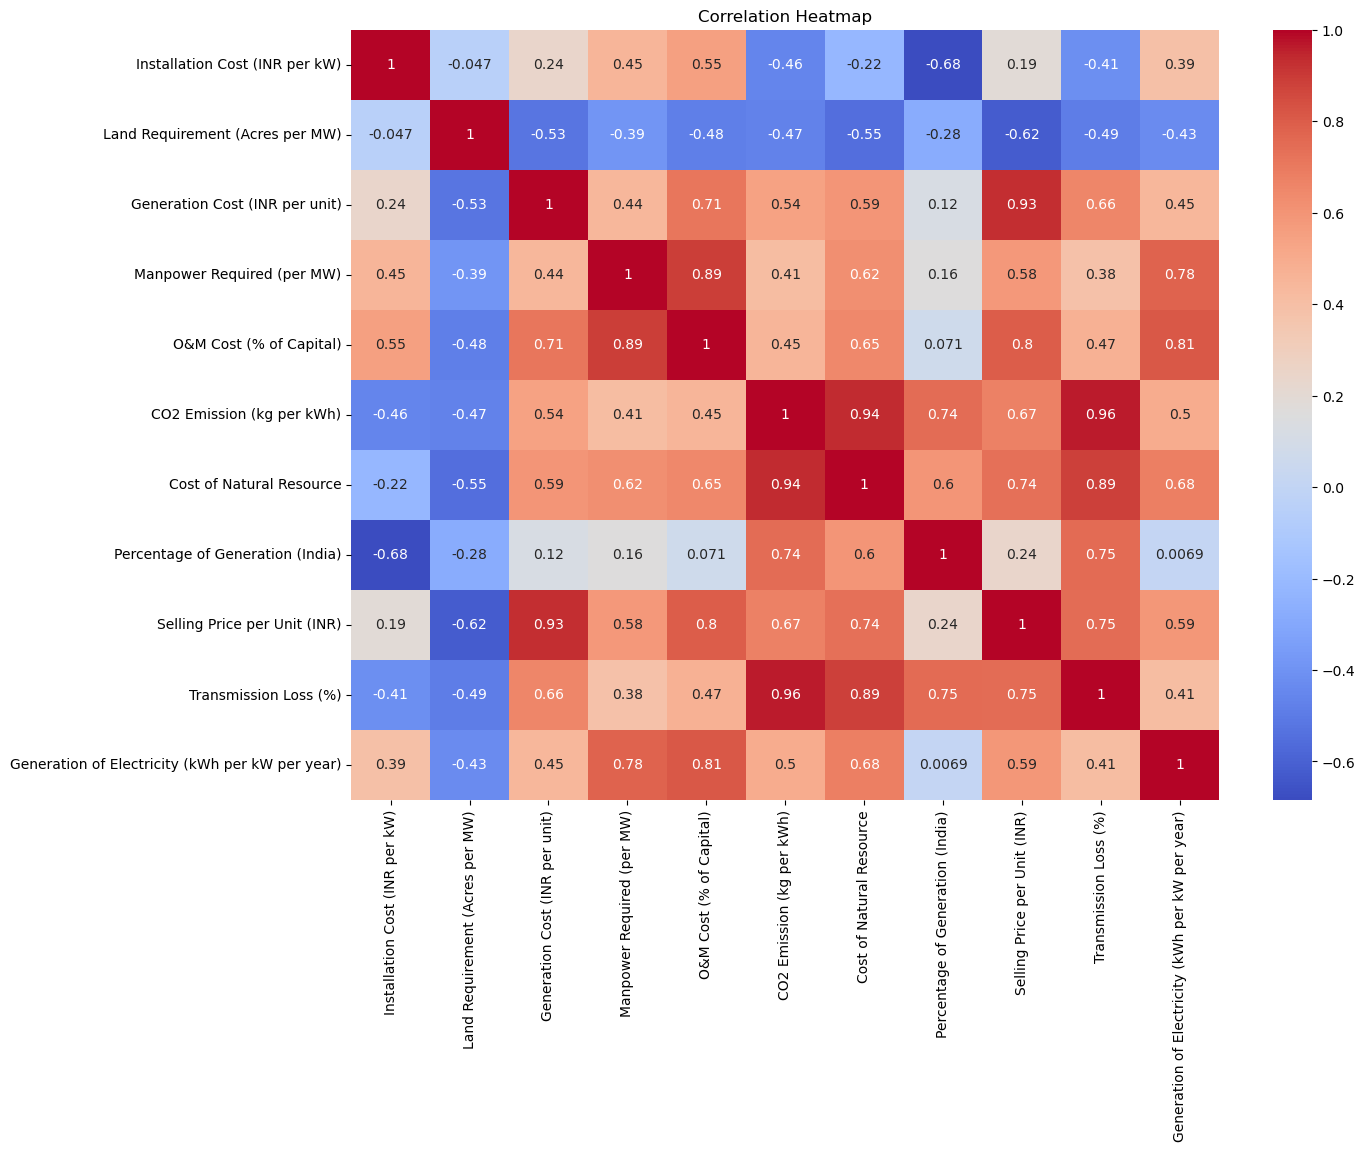

In [9]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## Data Preprocessing

In [10]:
# Encode Categorical Variables

df_encoded = df.copy()

label_encoders = {}

for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

df_encoded.head()


,Energy Source,Energy Type,Installation Cost (INR per kW),Land Requirement (Acres per MW),Generation Cost (INR per unit),Manpower Required (per MW),Automation Level,O&M Cost (% of Capital),Purpose of Energy,CO2 Emission (kg per kWh),...,Available Employment,Sustainability,Cost of Natural Resource,Percentage of Generation (India),Effect on Economy,Government Subsidy Availability,Selling Price per Unit (INR),Transmission Loss (%),Shutdown Risk,Generation of Electricity (kWh per kW per year)
0,1,0,52965,0.94,6.86,15,1,4.95,0,0.828,...,0,1,2951,53.17,2,1,7.43,20.60,2,8126
1,6,1,131277,4.27,6.60,5,0,3.75,0,0.000,...,1,3,0,1.97,3,1,7.19,9.20,2,4459
2,7,1,54559,2.19,3.31,5,0,2.05,0,0.020,...,2,3,0,34.77,3,0,4.29,7.25,1,2860
3,5,1,41085,5.45,4.37,5,0,1.44,0,0.046,...,0,3,0,24.70,3,0,4.16,7.99,1,1470
4,1,0,46733,0.98,6.09,16,1,4.93,0,0.847,...,0,1,3081,49.84,2,1,8.55,19.80,2,8130


## Feature Selection

In [11]:
# Features and Target

X = df_encoded.drop('Energy Type', axis=1)
y = df_encoded['Energy Type']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (100, 21)
Target Shape: (100,)


## Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 80
Testing Samples: 20


## Random Forest Classification

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, rf_predictions))


Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



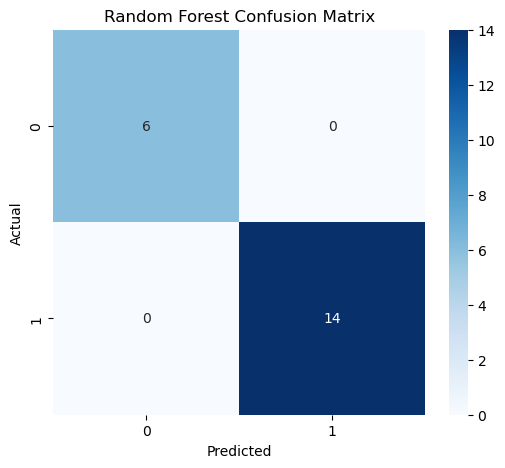

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature Importance

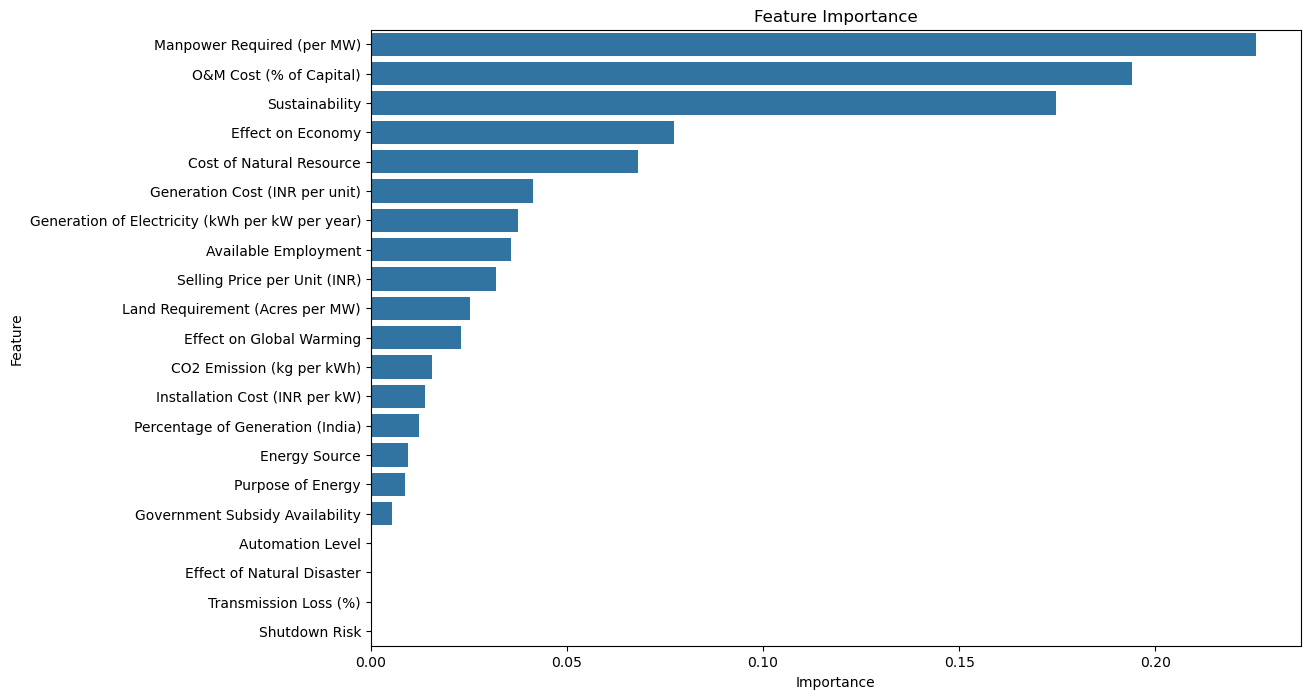

,Feature,Importance
4,Manpower Required (per MW),0.225754
6,O&M Cost (% of Capital),0.193967
12,Sustainability,0.174526
15,Effect on Economy,0.077220
13,Cost of Natural Resource,0.068079
3,Generation Cost (INR per unit),0.041357
20,Generation of Electricity (kWh per kW per year),0.037614
11,Available Employment,0.035843
17,Selling Price per Unit (INR),0.031791
2,Land Requirement (Acres per MW),0.025232


In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

importance.head(10)


## Decision Tree Model

In [16]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 1.0


## XGBoost Model

In [17]:
if xgb_available:

    xgb_model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train, y_train)

    xgb_predictions = xgb_model.predict(X_test)

    xgb_accuracy = accuracy_score(y_test, xgb_predictions)

    print("XGBoost Accuracy:", xgb_accuracy)

else:
    print("XGBoost is not installed in this environment.")


XGBoost Accuracy: 1.0


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:28:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model Comparison

In [18]:
models = ['Random Forest', 'Decision Tree']
accuracies = [rf_accuracy, dt_accuracy]

if xgb_available:
    models.append('XGBoost')
    accuracies.append(xgb_accuracy)

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison_df


,Model,Accuracy
0,Random Forest,1.0
1,Decision Tree,1.0
2,XGBoost,1.0


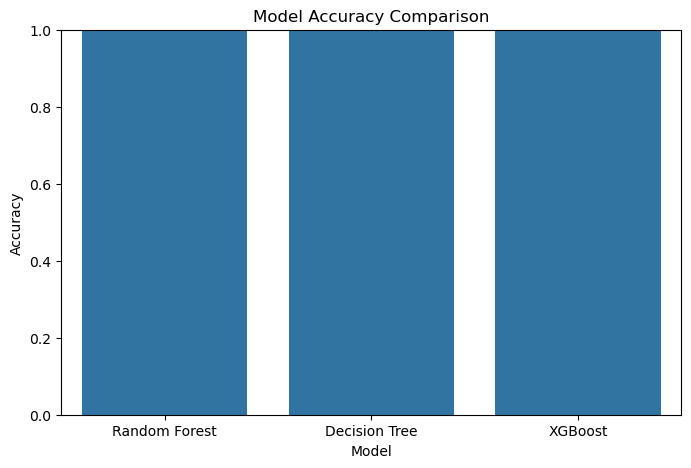

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


# Business Insights

## Key Findings
1. Renewable energy sources produce significantly lower CO2 emissions.
2. Solar and wind energy have higher sustainability scores.
3. Fossil fuels show higher environmental impact and global warming effects.
4. Government subsidies strongly support renewable energy growth.
5. Renewable sources create more long-term sustainable employment opportunities.

---

# Conclusion

This project successfully analyzed renewable and non-renewable energy sources in India using Machine Learning and Data Analytics techniques.

The study shows that renewable energy sources:
- Are more sustainable
- Produce less pollution
- Receive better government support
- Provide long-term environmental benefits

Among the machine learning models tested:
- Random Forest performed effectively for energy type prediction.
- Feature importance analysis identified the major sustainability indicators.

This capstone project can help policymakers, researchers, and industries make informed decisions about future energy investments in India.
